In [1]:
## DOWNLOADING THE TRAINING DATA AND CONFIG FILE ##
!wget --quiet https://github.com/mir-group/nequip-tutorial/raw/refs/heads/main/config.yaml
!wget --quiet https://github.com/mir-group/nequip-tutorial/raw/refs/heads/main/sitraj.xyz

## TRAIN NEQUIP ##
!rm -rf ./results
!mkdir ./results
!/pscratch/sd/v/vladygin/nequip-allegro-lammps/nequip-allegro/bin/nequip-train -cn config.yaml

[2025-05-03 23:05:29,076][nequip.utils.versions][INFO] - [rank: 0] Version Information:
[2025-05-03 23:05:29,077][nequip.utils.versions][INFO] - [rank: 0] torch 2.6.0a0+git1eba9b3
[2025-05-03 23:05:29,077][nequip.utils.versions][INFO] - [rank: 0] e3nn 0.5.6
[2025-05-03 23:05:29,077][nequip.utils.versions][INFO] - [rank: 0] nequip 0.7.0
[2025-05-03 23:05:29,077][nequip.utils.versions][INFO] - [rank: 0] allegro 0.4.0
[2025-05-03 23:05:29,077][nequip.scripts.train][INFO] - [rank: 0] This `nequip-train` run will perform the following tasks: ['train', 'test']
[2025-05-03 23:05:29,078][nequip.scripts.train][INFO] - [rank: 0] and use the output directory provided by Hydra: /pscratch/sd/v/vladygin/NaBr_project/ALLEGRO_setup/new_setup/SpinGNN/allegro/workdir/test_allegro/outputs/2025-05-03/23-05-29
[2025-05-03 23:05:29,182][nequip.scripts.train][INFO] - [rank: 0] Building datamodule ...
[2025-05-03 23:05:29,190][nequip.data.datamodule._base_datamodule][INFO] - [rank: 0] Found 1 training dataset

In [ ]:
# placeholder

In [4]:
ckpt_path = "./outputs/2025-05-01/17-10-06/last.ckpt"
output_path = "/pscratch/sd/v/vladygin/nequip-allegro-lammps/test_allegro/deployed.nequip.pth"

!/pscratch/sd/v/vladygin/nequip-allegro-lammps/nequip-allegro/bin/nequip-compile --mode torchscript --input-path {ckpt_path} --output-path {output_path} --device cuda

[2025-05-01 17:10:59,088][nequip.scripts.compile][INFO] - [rank: 0] Compiling for device: cuda
[2025-05-01 17:10:59,088][nequip.scripts.compile][INFO] - [rank: 0] Loading model for compilation from outputs/2025-05-01/17-10-06/last.ckpt ...
[2025-05-01 17:10:59,088][nequip.model.from_save][INFO] - [rank: 0] Loading model from checkpoint file: outputs/2025-05-01/17-10-06/last.ckpt ...
[2025-05-01 17:11:00,259][nequip.train.ema][INFO] - [rank: 0] Loading EMA weights for evaluation model.
[2025-05-01 17:11:00,666][nequip.scripts.compile][INFO] - [rank: 0] TorchScript model saved to /pscratch/sd/v/vladygin/nequip-allegro-lammps/test_allegro/deployed.nequip.pth


In [6]:
# @title Prepare files and run LAMMPS
from ase.io import read, write
example_atoms = read('./sitraj.xyz', index=0)
write('./si.data', example_atoms, format='lammps-data')

lammps_input = """
units	metal
atom_style atomic
dimension 3

# set newton on for pair_allegro (off for pair_nequip)
boundary p p p
read_data ../si.data

# if you want to run a larger system, simply replicate the system in space
# replicate 3 3 3

# allegro pair style
pair_style	allegro
pair_coeff	* * /pscratch/sd/v/vladygin/nequip-allegro-lammps/test/deployed.nequip.pth Si

mass 1 28.0855

velocity all create 300.0 1234567 loop geom

neighbor 1.0 bin
neigh_modify delay 5 every 1

timestep 0.001
thermo 10

dump dump_pos all custom 200 dump.xyz id type x y z

# nose-hoover thermostat, 300K
fix  1 all nvt temp 300 300 $(100*dt)

# compute rdf and average after some equilibration
comm_modify cutoff 7.0
compute rdfall all rdf 1000 cutoff 5.0
fix 2 all ave/time 1 2500 5000 c_rdfall[*] file si.rdf mode vector

# run 5ps
run 5000
"""
!rm -rf ./lammps_run
!mkdir lammps_run
with open("lammps_run/si_rdf.in", "w") as f:
    f.write(lammps_input)

!cd lammps_run/ && /pscratch/sd/v/vladygin/nequip-allegro-lammps/lammps/build/lmp -in si_rdf.in

LAMMPS (2 Apr 2025)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:99)
  using 1 OpenMP thread(s) per MPI task
Reading data file ...
  orthogonal box = (0 0 0) to (10.862 10.862 10.862)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  64 atoms
  read_data CPU = 0.001 seconds
NequIP/Allegro is using input precision d and output precision d
NequIP/Allegro: Loading model from /pscratch/sd/v/vladygin/nequip-allegro-lammps/test/deployed.nequip.pth
NequIP/Allegro: Freezing TorchScript model...
Type mapping:
NequIP/Allegro type | NequIP/Allegro name | LAMMPS type | LAMMPS name
0 | Si | 1 | Si
Neighbor list info ...
  update: every = 1 steps, delay = 5 steps, check = yes
  max neighbors/atom: 2000, page size: 100000
  master list distance cutoff = 6
  ghost atom cutoff = 7
  binsize = 3, bins = 4 4 4
  2 neighbor lists, perpetual/occasional/extra = 1 1 0
  (1) pair allegro, perpetual
      attributes: full, newton on, ghost
      pair build: full/bin/ghost


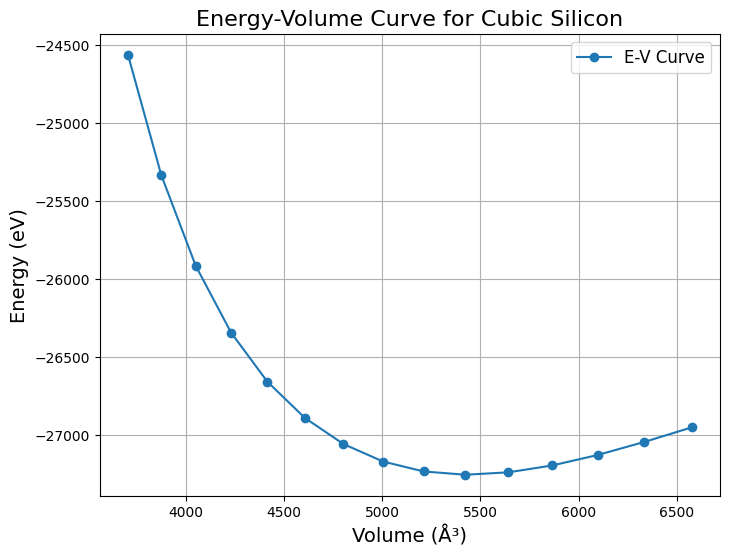

In [7]:
#@title Using ASE NequIP calculator to plot energy-volume curve
from ase import Atoms
from ase.build import bulk
import numpy as np
import matplotlib.pyplot as plt
from nequip.ase import NequIPCalculator

# Initialize the nequip calculator
calculator = NequIPCalculator.from_checkpoint_model(ckpt_path="./outputs/2025-05-01/17-10-06/last.ckpt",
                                                    chemical_symbols = ['Si'],
                                                    device='cpu' )

# Range of scaling factors for lattice constant
scaling_factors = np.linspace(0.95, 1.15, 15)
volumes = []
energies = []

# Loop through scaling factors, calculate energy, and collect volumes and energies
for scale in scaling_factors:

    # Generate the cubic silicon structure with 216 atoms
    scaled_si = bulk("Si", crystalstructure="diamond", a=5.43 * scale, cubic=True)
    scaled_si *= (3, 3, 3)  # Make a supercell (3x3x3) to get 216 atoms
    scaled_si.calc = calculator

    volume = scaled_si.get_volume()
    energy = scaled_si.get_potential_energy()
    volumes.append(volume)
    energies.append(energy)

# Plot the energy-volume curve
plt.figure(figsize=(8, 6))
plt.plot(volumes, energies, marker='o', label="E-V Curve")
plt.xlabel("Volume (Å³)", fontsize=14)
plt.ylabel("Energy (eV)", fontsize=14)
plt.title("Energy-Volume Curve for Cubic Silicon", fontsize=16)
plt.legend(fontsize=12)
plt.grid()
plt.show()
